In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
import nltk
from wordcloud import WordCloud 
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score , precision_score, recall_score, classification_report, make_scorer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
import warnings
warnings.filterwarnings('ignore')

## Exploratory Data Analysis

In [2]:
df = pd.read_csv("../input/Twitter_Data.csv")
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [3]:
df.isna().sum()

clean_text    4
category      7
dtype: int64

In [4]:
df.dropna(inplace=True)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 162969 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162969 non-null  object 
 1   category    162969 non-null  float64
dtypes: float64(1), object(1)
memory usage: 3.7+ MB


In [8]:
df['category'].unique()

array([-1.,  0.,  1.])

In [9]:
df.shape

(162969, 2)

In [10]:
df[df["category"]==-1].shape[0]

35509

In [11]:
df[df["category"]==0].shape[0]

55211

In [12]:
df[df["category"]==1].shape[0]

72249

## Data Preprocessing:

In [13]:
def remove_patterns(data, pattern):
    result = re.findall(pattern,data)
    for word in result:
        #re.sub(pattern, replacement, string, count=0, flags=0)
        data = re.sub(word, "", data)
    return data

In [14]:
# remove the @user tags from the text
df['cleaned'] = df['clean_text'].map(lambda x: remove_patterns(x, r"@[\w]+"))
df.head()

,clean_text,category,cleaned
0,when modi promised “minimum government maximum...,-1.0,when modi promised “minimum government maximum...
1,talk all the nonsense and continue all the dra...,0.0,talk all the nonsense and continue all the dra...
2,what did just say vote for modi welcome bjp t...,1.0,what did just say vote for modi welcome bjp t...
3,asking his supporters prefix chowkidar their n...,1.0,asking his supporters prefix chowkidar their n...
4,answer who among these the most powerful world...,1.0,answer who among these the most powerful world...


In [15]:
# df['cleaned'] = df['cleaned'].map(lambda x: remove_patterns(x, r"#[\w]+"))
# df.head()

In [16]:
# remove special characters
df['cleaned'] = df['cleaned'].str.replace(r"[^a-zA-Z\s]", "",regex=True)
df.head()

,clean_text,category,cleaned
0,when modi promised “minimum government maximum...,-1.0,when modi promised minimum government maximum ...
1,talk all the nonsense and continue all the dra...,0.0,talk all the nonsense and continue all the dra...
2,what did just say vote for modi welcome bjp t...,1.0,what did just say vote for modi welcome bjp t...
3,asking his supporters prefix chowkidar their n...,1.0,asking his supporters prefix chowkidar their n...
4,answer who among these the most powerful world...,1.0,answer who among these the most powerful world...


In [17]:
# remove words less than 3 characters
df["cleaned"] = df["cleaned"].apply(lambda x: " ".join([word.lower() for word in x.split() if len(word)>3 and word.lower() != 'modi']))
df.head()

,clean_text,category,cleaned
0,when modi promised “minimum government maximum...,-1.0,when promised minimum government maximum gover...
1,talk all the nonsense and continue all the dra...,0.0,talk nonsense continue drama will vote
2,what did just say vote for modi welcome bjp t...,1.0,what just vote welcome told rahul main campaig...
3,asking his supporters prefix chowkidar their n...,1.0,asking supporters prefix chowkidar their names...
4,answer who among these the most powerful world...,1.0,answer among these most powerful world leader ...


In [18]:
# tokenize the text column
tokenized = df["cleaned"].apply(lambda x: word_tokenize(x.lower()))
tokenized.head()

0    [when, promised, minimum, government, maximum,...
1        [talk, nonsense, continue, drama, will, vote]
2    [what, just, vote, welcome, told, rahul, main,...
3    [asking, supporters, prefix, chowkidar, their,...
4    [answer, among, these, most, powerful, world, ...
Name: cleaned, dtype: object

In [19]:
# remove stopwords from the text
stop_words = set(stopwords.words("english"))
tokenized = tokenized.apply(lambda x: [word for word in x if word not in stop_words])
tokenized.head()

0    [promised, minimum, government, maximum, gover...
1              [talk, nonsense, continue, drama, vote]
2    [vote, welcome, told, rahul, main, campaigner,...
3    [asking, supporters, prefix, chowkidar, names,...
4    [answer, among, powerful, world, leader, today...
Name: cleaned, dtype: object

In [20]:
# perform stemming on the tokens
steamer = PorterStemmer()
tokenized = tokenized.apply(lambda x: [steamer.stem(word) for word in x])
tokenized.head()

0    [promis, minimum, govern, maximum, govern, exp...
1                [talk, nonsens, continu, drama, vote]
2    [vote, welcom, told, rahul, main, campaign, th...
3    [ask, support, prefix, chowkidar, name, great,...
4    [answer, among, power, world, leader, today, t...
Name: cleaned, dtype: object

In [21]:
# for i in range(len(tokenized)):
#     tokenized[i] = " ".join(tokenized[i])
# df["cleaned"] = tokenized
# df.head()

# compine all words into one sentance in cleaned column
df["cleaned"] = tokenized.apply(lambda x: " ".join(x))
df.head()

,clean_text,category,cleaned
0,when modi promised “minimum government maximum...,-1.0,promis minimum govern maximum govern expect be...
1,talk all the nonsense and continue all the dra...,0.0,talk nonsens continu drama vote
2,what did just say vote for modi welcome bjp t...,1.0,vote welcom told rahul main campaign think relax
3,asking his supporters prefix chowkidar their n...,1.0,ask support prefix chowkidar name great servic...
4,answer who among these the most powerful world...,1.0,answer among power world leader today trump putin


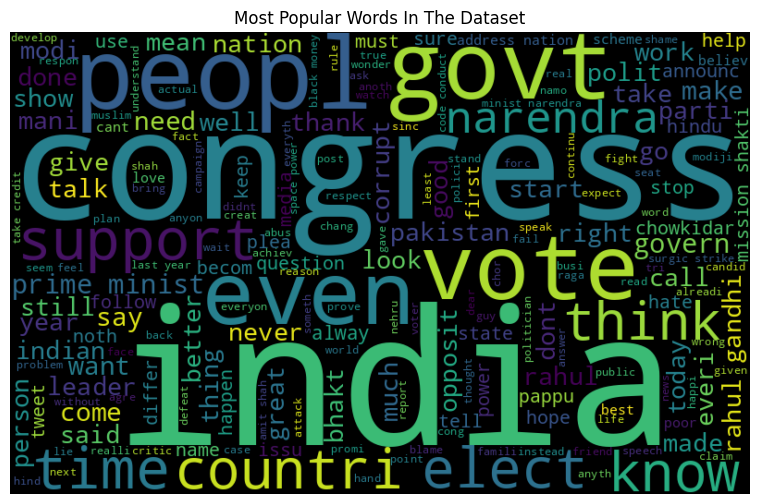

In [22]:
all_types = " ".join([sentence for sentence in df["cleaned"]])
word_cloud = WordCloud(width=800, height=500).generate(all_types)
plt.figure(figsize=(12,6))
plt.title("Most Popular Words In The Dataset")
plt.imshow(word_cloud, interpolation= "bilinear")
plt.axis("off")
plt.show()

In [23]:
neg_word = " ".join([sentence for sentence in df["cleaned"][df["category"]==-1]])
neutral_word = " ".join([sentence for sentence in df["cleaned"][df["category"]==0]])
pos_word = " ".join([sentence for sentence in df["cleaned"][df["category"]==1]])

pos_cloud = WordCloud(width=800, height=500, colormap = "Greens").generate(pos_word)
neutral_cloud = WordCloud(width=800, height=500, colormap = "Blues").generate(neutral_word)
neg_cloud = WordCloud(width=800, height=500, colormap = "Reds").generate(neg_word)

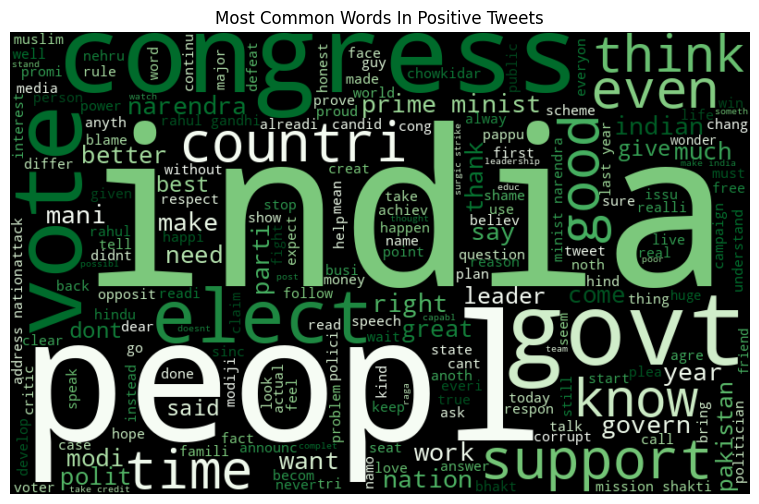

In [24]:
plt.figure(figsize=(12,6))
plt.title("Most Common Words In Positive Tweets")
plt.imshow(pos_cloud, interpolation= "bilinear")
plt.axis("off")
plt.show()

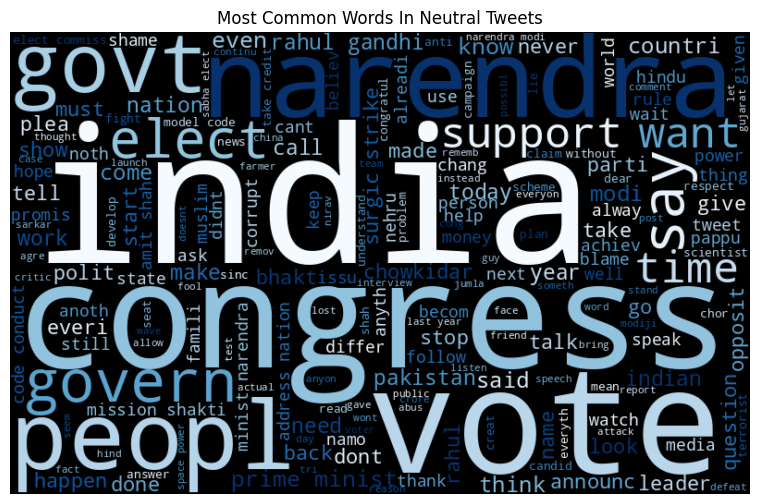

In [42]:
plt.figure(figsize=(12,6))
plt.title("Most Common Words In Neutral Tweets")
plt.imshow(neutral_cloud, interpolation= "bilinear")
plt.axis("off")
plt.show()

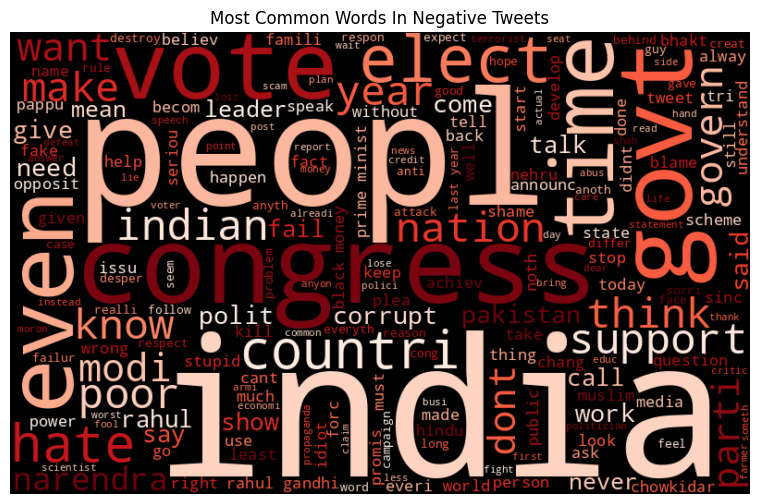

In [26]:
plt.figure(figsize=(12,6))
plt.title("Most Common Words In Negative Tweets")
plt.imshow(neg_cloud, interpolation= "bilinear")
plt.axis("off")
plt.show()

In [27]:
common_neg = tokenized[df["category"]==-1]
common_neg = [lst for lst in common_neg]
common_neg = [item for sublist in common_neg for item in sublist]

common_neutral = tokenized[df["category"]==0]
common_neutral = [lst for lst in common_neutral]
common_neutral = [item for sublist in common_neutral for item in sublist]

common_pos = tokenized[df["category"]==1]
common_pos = [lst for lst in common_pos]
common_pos = [item for sublist in common_pos for item in sublist]

In [28]:
freq_neg = nltk.FreqDist(common_neg)
negative = pd.DataFrame({'Negative': list(freq_neg.keys()), 'Count': list(freq_neg.values())}).sort_values(by='Count')

freq_neutral = nltk.FreqDist(common_neutral)
neutral = pd.DataFrame({'Neutral': list(freq_neutral.keys()), 'Count': list(freq_neutral.values())}).sort_values(by='Count')

freq_pos = nltk.FreqDist(common_pos)
positive = pd.DataFrame({'Positive': list(freq_pos.keys()), 'Count': list(freq_pos.values())}).sort_values(by='Count')

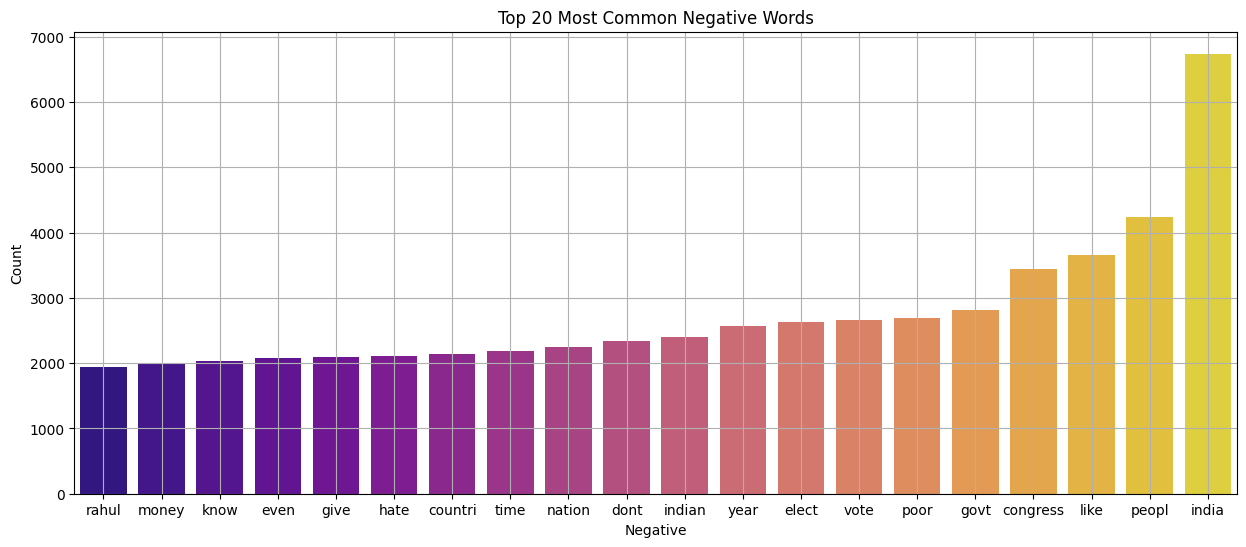

In [29]:
top_neg = negative.tail(20)
plt.figure(figsize=(15,6))
colors = plt.cm.plasma(np.linspace(0, 1, 17))
sns.barplot(x= top_neg["Negative"], y=top_neg['Count'], palette="plasma")
plt.title("Top 20 Most Common Negative Words")
plt.grid()
plt.show()

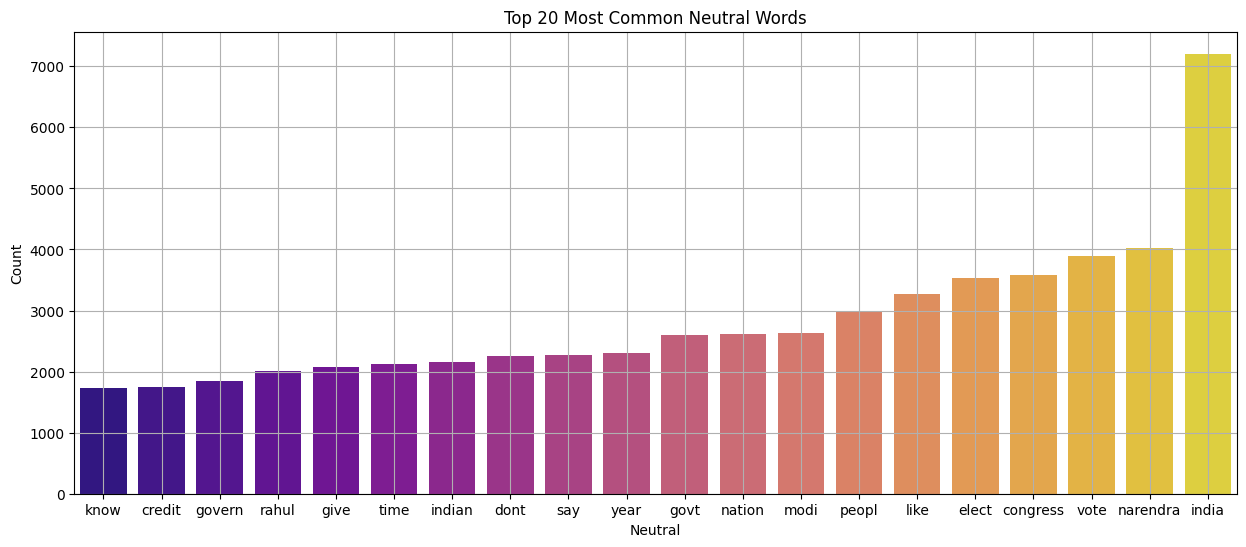

In [30]:
top_neutral = neutral.tail(20)
plt.figure(figsize=(15,6))
colors = plt.cm.plasma(np.linspace(0, 1, 17))
sns.barplot(x= top_neutral["Neutral"], y=top_neutral['Count'], palette="plasma")
plt.title("Top 20 Most Common Neutral Words")
plt.grid()
plt.show()

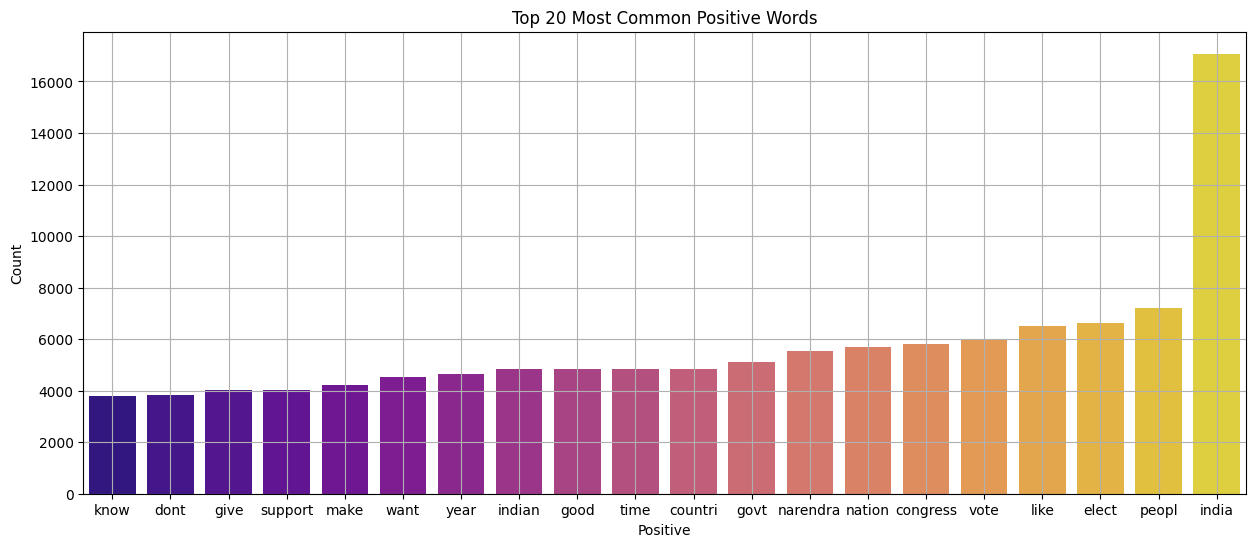

In [31]:
top_pos = positive.tail(20)
plt.figure(figsize=(15,6))
colors = plt.cm.plasma(np.linspace(0, 1, 17))
sns.barplot(x= top_pos["Positive"], y=top_pos['Count'], palette="plasma")
plt.title("Top 20 Most Common Positive Words")
plt.grid()
plt.show()

## Data Splitting

In [32]:
# perform vectorization for the text
vectorizer = CountVectorizer(max_df=0.90, min_df=2, stop_words='english')
bow = vectorizer.fit_transform(df["cleaned"])

In [33]:
bow[0].toarray()

array([[0, 0, 0, ..., 0, 0, 0]], shape=(1, 26529))

In [34]:
# ros = RandomOverSampler(random_state=42)
# x_resampled, y_resampled = ros.fit_resample(bow, df['category'])

In [35]:
# df_sample, _ = train_test_split(df, train_size=0.2, stratify=df["category"], random_state=42)
# df_sample.head()
# df_sample['category'].value_counts(normalize=True),df['category'].value_counts(normalize=True),df_sample.shape

In [36]:
# vectorizer = CountVectorizer(max_df=0.90, min_df=2, stop_words='english')
# bow_sample = vectorizer.fit_transform(df_sample["cleaned"])

In [37]:
# split the data into train and test
x_train, x_test, y_train, y_test = train_test_split(bow, df['category'], random_state=42, test_size=0.25)
# x_train, x_test, y_train, y_test = train_test_split(bow_sample, df_sample['category'], random_state=42, test_size=0.25)
# x_train, x_test, y_train, y_test = train_test_split(x_resampled, y_resampled, random_state=42, test_size=0.3)

In [38]:
# smote = SMOTE()
# x_resampled, y_resampled = smote.fit_resample(x_train, y_train)

## Model Trainning

In [ ]:
model = LinearSVC(C=0.1,class_weight='balanced')
model.fit(x_train, y_train)
# model.fit(x_resampled, y_resampled)

LinearSVC(C=0.1, class_weight='balanced')

In [40]:
pred = model.predict(x_test)
f1_score(y_test,pred,average="weighted"),accuracy_score(y_test, pred)

(0.7956768064292462, 0.7960631274083891)

In [41]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

        -1.0       0.75      0.74      0.74      8933
         0.0       0.75      0.90      0.81     13860
         1.0       0.87      0.75      0.81     17950

    accuracy                           0.80     40743
   macro avg       0.79      0.79      0.79     40743
weighted avg       0.80      0.80      0.80     40743



In [ ]:
f1_scorer = make_scorer(f1_score, average='weighted') 
svc = LinearSVC(class_weight='balanced', max_iter=10000)

param_grid = {'C': [0.01, 0.1, 1, 10, 100],'dual': [False],}

grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_search.fit(x_train, y_train)

print("Best F1 Score:", grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


In [ ]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
print(classification_report(y_test, y_pred))

In [ ]:
import pickle
with open("../model/sentiment_analysis.pkl", 'wb') as f:
    pickle.dump(model, f)

In [ ]:
import pickle
with open("../model/vectorizer.pkl", 'wb') as f:
    pickle.dump(vectorizer, f)